# EDA Validación Satélite vs Tierra — S5P vs DAGMA

Comparación cuantitativa entre datos satelitales **Sentinel-5P** y mediciones
en tierra de la red **DAGMA** para los contaminantes NO₂, SO₂ y O₃.

| Fig | Descripción |
|-----|-------------|
| 1 | Scatter S5P vs DAGMA por contaminante |
| 2 | Serie temporal dual (S5P + DAGMA superpuestos) |
| 3 | Mapa de sesgo espacial por estación |
| 4 | Diagrama de Taylor (std normalizada vs correlación) |
| 5 | Densidad condicional del error vs nubosidad |
| 6 | RMSE móvil en el tiempo |


## ⚙️ 1. Imports y Configuración

In [1]:
import json, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
import rasterio

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

# ── Rutas ────────────────────────────────────────────────
ROOT         = Path().resolve().parent.parent        # ajustar según estructura
S5P_L3_DIR   = ROOT / "data" / "sentinel5p" / "l3"
DAGMA_CSV_DIR = ROOT / "data" / "dagma" / "raw"
OUT_DIR      = ROOT / "outputs" / "eda" / "validacion"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 150

# ── Parámetros ───────────────────────────────────────────
TARGETS = {
    "NO2": "tropospheric_NO2_column_number_density",
    "SO2": "SO2_column_number_density",
    "O3":  "O3_column_number_density",
}

DAGMA_STATIONS = {
    "ERA OBRERO":            (-76.5065, 3.4573),
    "LA ERMITA":             (-76.532,  3.451),
    "UNIVERSIDAD DEL VALLE": (-76.534,  3.375),
    "PANCE":                 (-76.5313, 3.3045),
    "BASE AÉREA":            (-76.488,  3.478),
    "COMPARTIR":             (-76.4666, 3.4283),
    "LA FLORA":              (-76.518,  3.478),
    "CAÑAVERALEJO":          (-76.511,  3.417),
    "TRANSITORIA-NAVARRO":   (-76.482,  3.426),
    "ACOPI":                 (-76.5019, 3.5164),
    "LAS AMÉRICAS":          (-76.4994, 3.5371),
    "YUMBO-ALBERTO MENDOZA": (-76.495,  3.570),
}

COLORS = {"NO2": "#E53935", "SO2": "#FF9800", "O3": "#4CAF50"}

def lonlat_to_pixel(lon, lat, bbox=(-77.00, 5.00, -75.79, 2.99)):
    col = int(round((lon - bbox[0]) / 0.01))
    row = int(round((bbox[1] - lat) / 0.01))
    return row, col

def savefig(name):
    """Guarda la figura actual y la muestra inline."""
    p = OUT_DIR / f"{name}.png"
    plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()
    print(f"✓ {p.name}")
    return p

print("✅ Configuración lista")
print(f"   S5P dir   : {S5P_L3_DIR}")
print(f"   DAGMA dir : {DAGMA_CSV_DIR}")
print(f"   Output    : {OUT_DIR}")


✅ Configuración lista
   S5P dir   : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/data/sentinel5p/l3
   DAGMA dir : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/data/dagma/raw
   Output    : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion


## 📥 2. Carga de datos DAGMA (ground truth)

In [2]:
print("Cargando DAGMA ground truth...")
dagma_files  = sorted(DAGMA_CSV_DIR.glob("g4t8_*.csv"))
dagma_chunks = []

for f in dagma_files:
    for chunk in pd.read_csv(
        f,
        usecols=["nombre_est","msfl_code","med_concentracion_estandar",
                 "med_fecha_inicio","latitud","longitud","nombre_fgda"],
        chunksize=50000, encoding="utf-8", on_bad_lines="skip",
    ):
        chunk["fecha"] = pd.to_datetime(chunk["med_fecha_inicio"], errors="coerce")
        chunk["valor"] = pd.to_numeric(chunk["med_concentracion_estandar"], errors="coerce")
        chunk = chunk.dropna(subset=["fecha","valor"])
        dagma_chunks.append(
            chunk[["nombre_est","msfl_code","valor","fecha","latitud","longitud","nombre_fgda"]]
        )

dagma = pd.concat(dagma_chunks, ignore_index=True)
dagma["fecha_dia"] = dagma["fecha"].dt.date

print(f"  DAGMA: {len(dagma):,} registros")
print(f"  Estaciones únicas: {dagma['nombre_est'].nunique()}")
print(f"  Variables únicas : {dagma['msfl_code'].unique().tolist()}")
dagma.head(3)


Cargando DAGMA ground truth...
  DAGMA: 3,829,785 registros
  Estaciones únicas: 23
  Variables únicas : ['PLiquida', 'RGlobal', 'HAire2', 'VViento', 'P', 'DViento', 'SO2', 'PM10', 'TAire2', 'O3', 'PM2.5', 'HAire10', 'TAire10', 'NO2', 'NO', 'CO']


,nombre_est,msfl_code,valor,fecha,latitud,longitud,nombre_fgda,fecha_dia
0,ERA OBRERO,PLiquida,0.25,2020-01-01,3.457317,-76.506539,DAGMA,2020-01-01
1,ERA OBRERO,RGlobal,0.00,2020-01-01,3.457317,-76.506539,DAGMA,2020-01-01
2,PANCE,HAire2,92.90,2020-01-01,3.304517,-76.531252,DAGMA,2020-01-01


## 🔗 3. Emparejamiento S5P ↔ DAGMA

In [3]:
print("Construyendo inventario de fechas S5P...")
date_inventory = []
for yd in sorted(S5P_L3_DIR.iterdir()):
    if not yd.is_dir(): continue
    try: y = int(yd.name)
    except: continue
    for md in sorted(yd.iterdir()):
        if not md.is_dir(): continue
        for dd in sorted(md.iterdir()):
            if not dd.is_dir(): continue
            try: m, d = int(md.name), int(dd.name); dt = pd.Timestamp(y, m, d)
            except: continue
            date_inventory.append((dt, dd))

date_map = {dt.date(): dd for dt, dd in date_inventory}
print(f"  Fechas S5P disponibles: {len(date_map)}")

print("\nEmparejando S5P con DAGMA...")
records   = []
n_matched = 0

for i, (fecha_dia, station_group) in enumerate(dagma.groupby("fecha_dia")):
    if fecha_dia not in date_map: continue
    day_dir     = date_map[fecha_dia]
    cloud_path  = day_dir / "CLOUD.tif"
    if not cloud_path.exists(): continue
    try:
        with rasterio.open(cloud_path) as src:
            cloud = src.read(1).astype(np.float32)
    except: continue

    arrays = {}
    for prod in TARGETS:
        tp = day_dir / f"{prod}.tif"
        if tp.exists():
            try:
                with rasterio.open(tp) as src:
                    arrays[prod] = src.read(1).astype(np.float32)
            except: pass

    if not arrays: continue

    for _, row in station_group.iterrows():
        st_name = row["nombre_est"]
        var     = row["msfl_code"]
        if var not in TARGETS: continue
        lon, lat = row["longitud"], row["latitud"]
        r, c = lonlat_to_pixel(lon, lat)
        if r < 0 or r >= cloud.shape[0] or c < 0 or c >= cloud.shape[1]: continue

        cloud_val = cloud[r, c]
        is_clean  = cloud_val <= 0.3
        s5p_val   = np.nan
        if var in arrays:
            s5p_arr = arrays[var]
            if r < s5p_arr.shape[0] and c < s5p_arr.shape[1]:
                s5p_val = s5p_arr[r, c]

        if not np.isnan(s5p_val) and s5p_val > 0:
            records.append({
                "fecha": fecha_dia, "estacion": st_name, "variable": var,
                "dagma": row["valor"], "s5p": s5p_val,
                "cloud_frac": float(cloud_val), "is_clean": is_clean,
                "lon": lon, "lat": lat,
            })
            n_matched += 1

    if (i+1) % 500 == 0:
        print(f"  {i+1} fechas procesadas | {n_matched} emparejamientos...")

match_df = pd.DataFrame(records)
match_df["s5p_umol"] = match_df["s5p"] * 1e6          # mol/m² → µmol/m²

print(f"\n✅ Total emparejamientos: {len(match_df):,}")
for var in TARGETS:
    n = len(match_df[match_df["variable"] == var])
    print(f"   {var}: {n:,}")

if len(match_df) < 50:
    raise RuntimeError("Pocos datos emparejados. Verifique que los directorios S5P y DAGMA existan.")


Construyendo inventario de fechas S5P...
  Fechas S5P disponibles: 1827

Emparejando S5P con DAGMA...
  500 fechas procesadas | 57768 emparejamientos...
  1000 fechas procesadas | 98804 emparejamientos...
  1500 fechas procesadas | 122772 emparejamientos...

✅ Total emparejamientos: 160,344
   NO2: 7,987
   SO2: 16,439
   O3: 135,918


---
## 📊 Visualizaciones

### Fig 1 · Scatter S5P vs DAGMA — por contaminante (sólo píxeles limpios)

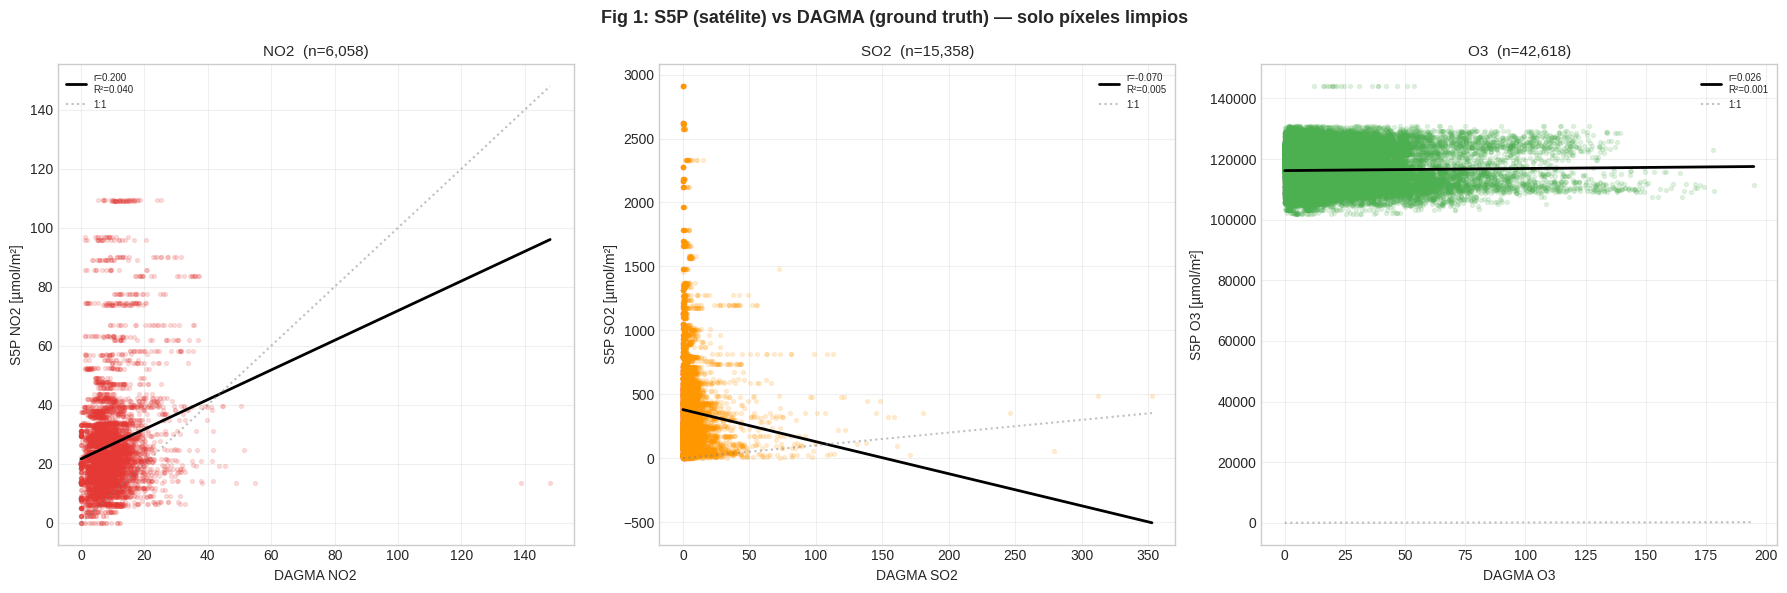

✓ 01_scatter_s5p_vs_dagma.png


PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion/01_scatter_s5p_vs_dagma.png')

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, TARGETS):
    dv = match_df[(match_df["variable"] == var) & match_df["is_clean"]]
    if len(dv) < 10:
        ax.text(0.5, 0.5, f"{var}: n={len(dv)}", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        continue

    sl, ic, r, p, _ = stats.linregress(dv["dagma"], dv["s5p_umol"])
    ax.scatter(dv["dagma"], dv["s5p_umol"],
               alpha=0.15, s=8, c=COLORS[var])

    xf = np.linspace(dv["dagma"].min(), dv["dagma"].max(), 100)
    ax.plot(xf, sl*xf + ic, "k-",   lw=2, label=f"r={r:.3f}\nR²={r**2:.3f}")
    ax.plot(xf, xf,         "gray", ls=":", alpha=0.5, label="1:1")

    ax.set_xlabel(f"DAGMA {var}")
    ax.set_ylabel(f"S5P {var} [µmol/m²]")
    ax.set_title(f"{var}  (n={len(dv):,})", fontsize=11)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle("Fig 1: S5P (satélite) vs DAGMA (ground truth) — solo píxeles limpios",
             fontweight="bold", fontsize=13)
fig.tight_layout()
savefig("01_scatter_s5p_vs_dagma")


### Fig 2 · Serie temporal dual — S5P + DAGMA (media diaria)

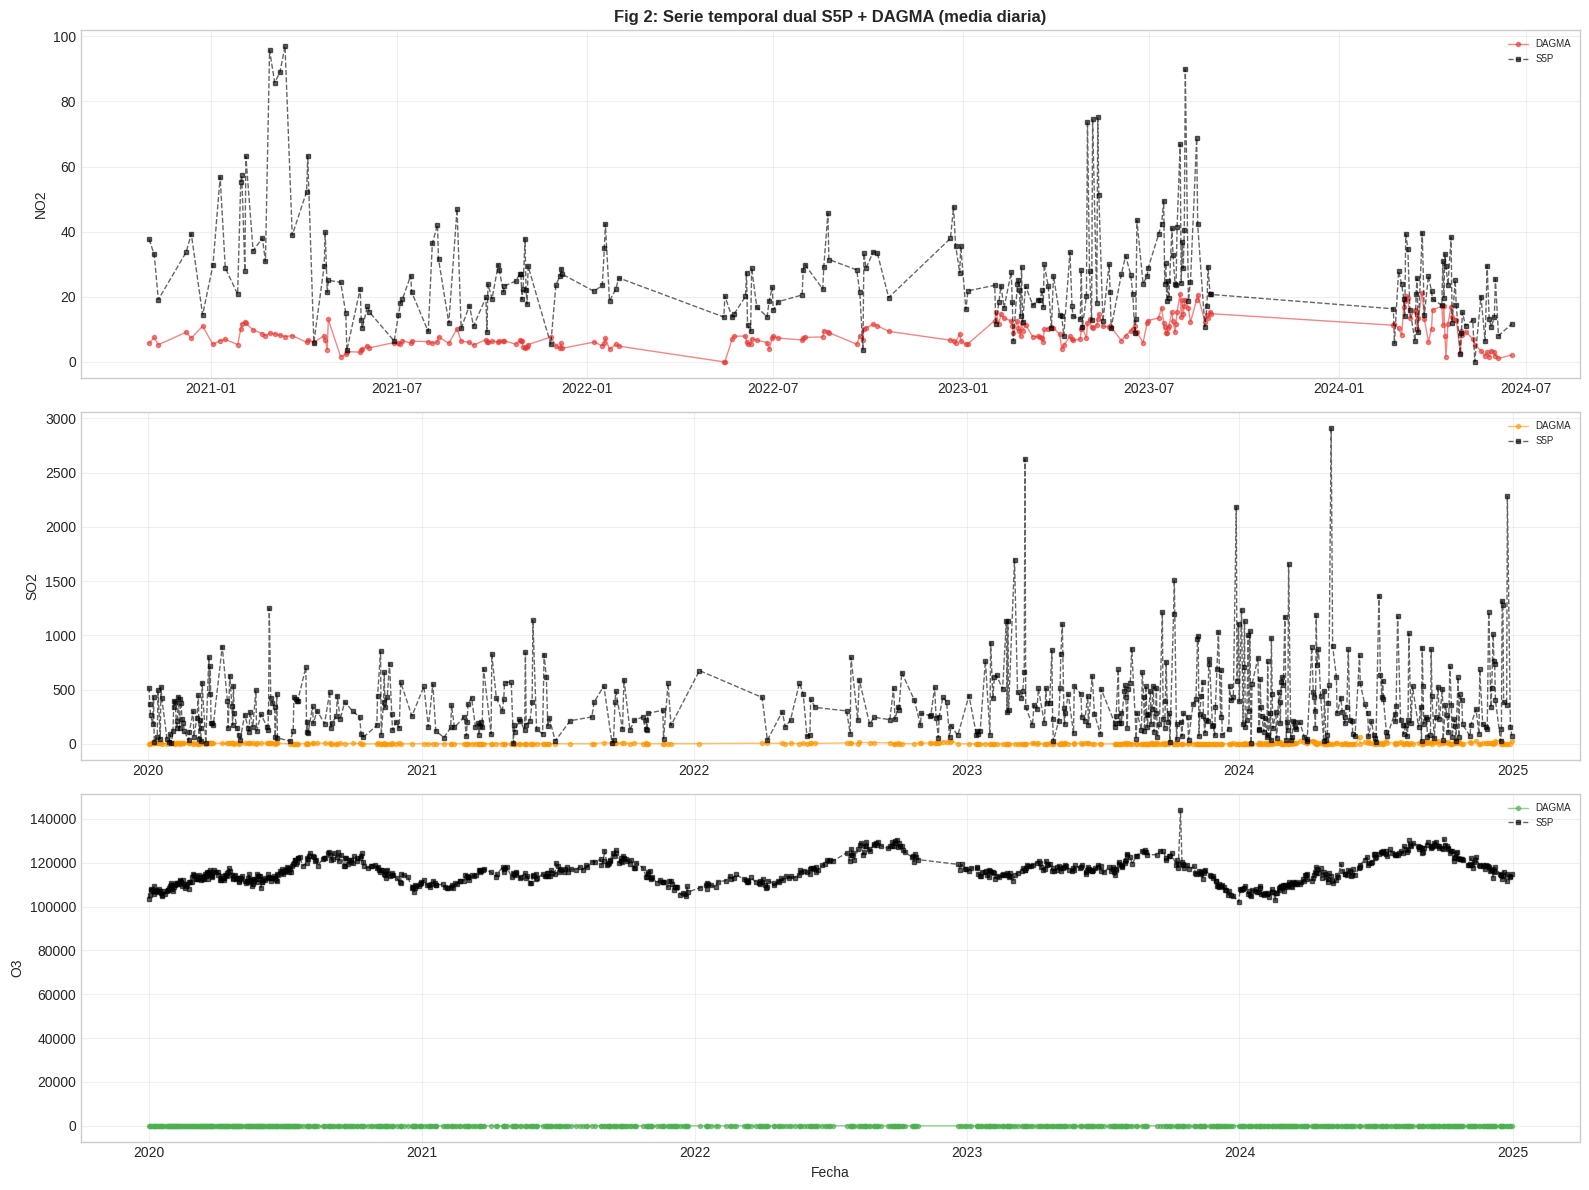

✓ 02_serie_temporal_dual.png


PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion/02_serie_temporal_dual.png')

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, var in zip(axes, TARGETS):
    dv = match_df[(match_df["variable"] == var) & match_df["is_clean"]]
    if len(dv) < 10:
        ax.text(0.5, 0.5, f"{var}: datos insuficientes", ha="center", va="center",
                transform=ax.transAxes)
        continue

    d_daily = dv.groupby("fecha")["dagma"].mean()
    s_daily = dv.groupby("fecha")["s5p_umol"].mean()
    common  = sorted(set(d_daily.index) & set(s_daily.index))

    ax.plot(common, [d_daily.get(d, np.nan) for d in common],
            "o-", lw=1, markersize=3, color=COLORS[var], alpha=0.6, label="DAGMA")
    ax.plot(common, [s_daily.get(d, np.nan) for d in common],
            "s--", lw=1, markersize=3, color="black", alpha=0.6, label="S5P")
    ax.set_ylabel(var, fontsize=10); ax.legend(fontsize=7); ax.grid(alpha=0.3)

axes[-1].set_xlabel("Fecha")
axes[0].set_title("Fig 2: Serie temporal dual S5P + DAGMA (media diaria)",
                  fontweight="bold", fontsize=12)
fig.tight_layout()
savefig("02_serie_temporal_dual")


### Fig 3 · Mapa de sesgo espacial por estación

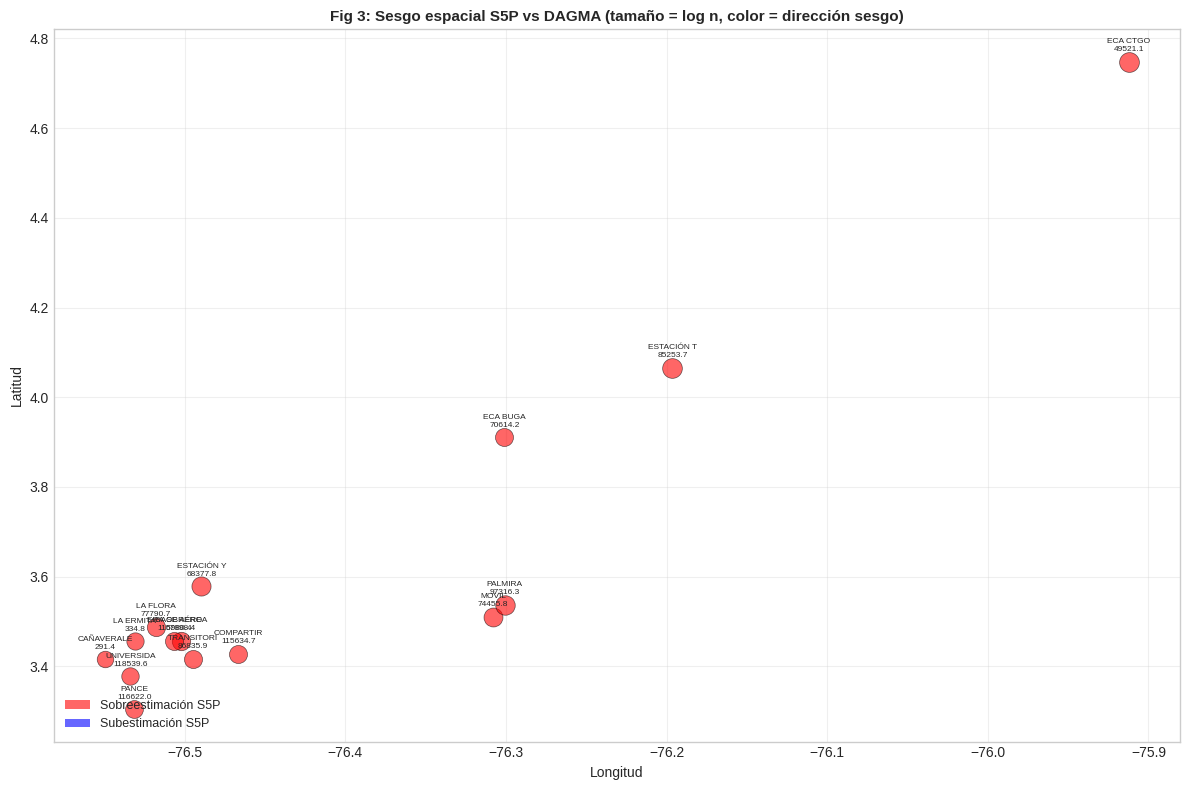

✓ 03_mapa_sesgo.png


PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion/03_mapa_sesgo.png')

In [6]:
bias_by_station = (
    match_df[match_df["is_clean"]]
    .groupby(["estacion","lon","lat"])
    .agg(
        bias_mean=("s5p_umol", "mean"),
        n=("dagma", "count"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 8))

for _, r in bias_by_station.iterrows():
    size  = np.log10(r["n"] + 1) * 50
    color = "red" if r["bias_mean"] > 0 else "blue"
    ax.scatter(r["lon"], r["lat"],
               s=size, c=color, alpha=0.6, edgecolors="black", linewidth=0.5)
    ax.annotate(
        f"{r['estacion'][:10]}\n{r['bias_mean']:.1f}",
        (r["lon"], r["lat"]),
        fontsize=6, ha="center", va="bottom",
        xytext=(0, 6), textcoords="offset points",
    )

# Leyenda manual de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red",  alpha=0.6, label="Sobreestimación S5P"),
    Patch(facecolor="blue", alpha=0.6, label="Subestimación S5P"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower left")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud"); ax.grid(alpha=0.3)
ax.set_title("Fig 3: Sesgo espacial S5P vs DAGMA (tamaño = log n, color = dirección sesgo)",
             fontweight="bold", fontsize=11)
fig.tight_layout()
savefig("03_mapa_sesgo")


### Fig 4 · Diagrama de Taylor (std normalizada vs correlación)

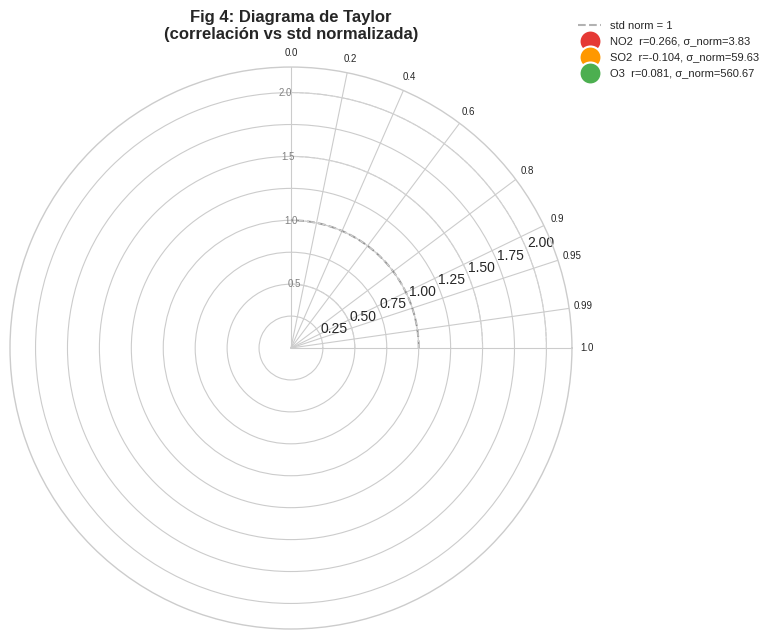

✓ 04_diagrama_taylor.png


PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion/04_diagrama_taylor.png')

In [7]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

# Arco de referencia (r=1)
theta_ref = np.linspace(0, np.pi/2, 100)
ax.plot(theta_ref, np.ones_like(theta_ref), "k--", alpha=0.3, label="std norm = 1")

# Arcos de std constante
for std_level in [0.5, 1.0, 1.5, 2.0]:
    ax.plot(theta_ref, np.full_like(theta_ref, std_level),
            color="lightgray", lw=0.8, ls="--")
    ax.text(np.pi/2 + 0.05, std_level, f"{std_level:.1f}",
            fontsize=7, color="gray", va="center")

for var in TARGETS:
    dv = match_df[(match_df["variable"] == var) & match_df["is_clean"]]
    if len(dv) < 10: continue
    s = dv.groupby("fecha")["s5p_umol"].mean()
    d = dv.groupby("fecha")["dagma"].mean()
    common = sorted(set(s.index) & set(d.index))
    s_v = np.array([s[c] for c in common])
    d_v = np.array([d[c] for c in common])
    if len(s_v) < 5: continue

    r_val, _  = stats.pearsonr(s_v, d_v)
    norm_std  = np.std(s_v) / (np.std(d_v) + 1e-10)
    theta_val = np.arccos(min(max(r_val, -0.999), 0.999))

    ax.scatter(theta_val, norm_std, s=250, c=COLORS[var],
               edgecolors="white", linewidth=1.5, zorder=5,
               label=f"{var}  r={r_val:.3f}, σ_norm={norm_std:.2f}")
    ax.annotate(var, (theta_val, norm_std),
                textcoords="offset points", xytext=(10, 10), fontsize=10, fontweight="bold")

ax.set_ylim(0, 2.2)
ax.set_xticks(np.arccos([1.0, 0.99, 0.95, 0.9, 0.8, 0.6, 0.4, 0.2, 0.0]))
ax.set_xticklabels(["1.0","0.99","0.95","0.9","0.8","0.6","0.4","0.2","0.0"], fontsize=7)
ax.set_title("Fig 4: Diagrama de Taylor\n(correlación vs std normalizada)",
             fontweight="bold", pad=20)
ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.35, 1.1))
fig.tight_layout()
savefig("04_diagrama_taylor")


### Fig 5 · Error relativo S5P vs DAGMA en función de nubosidad

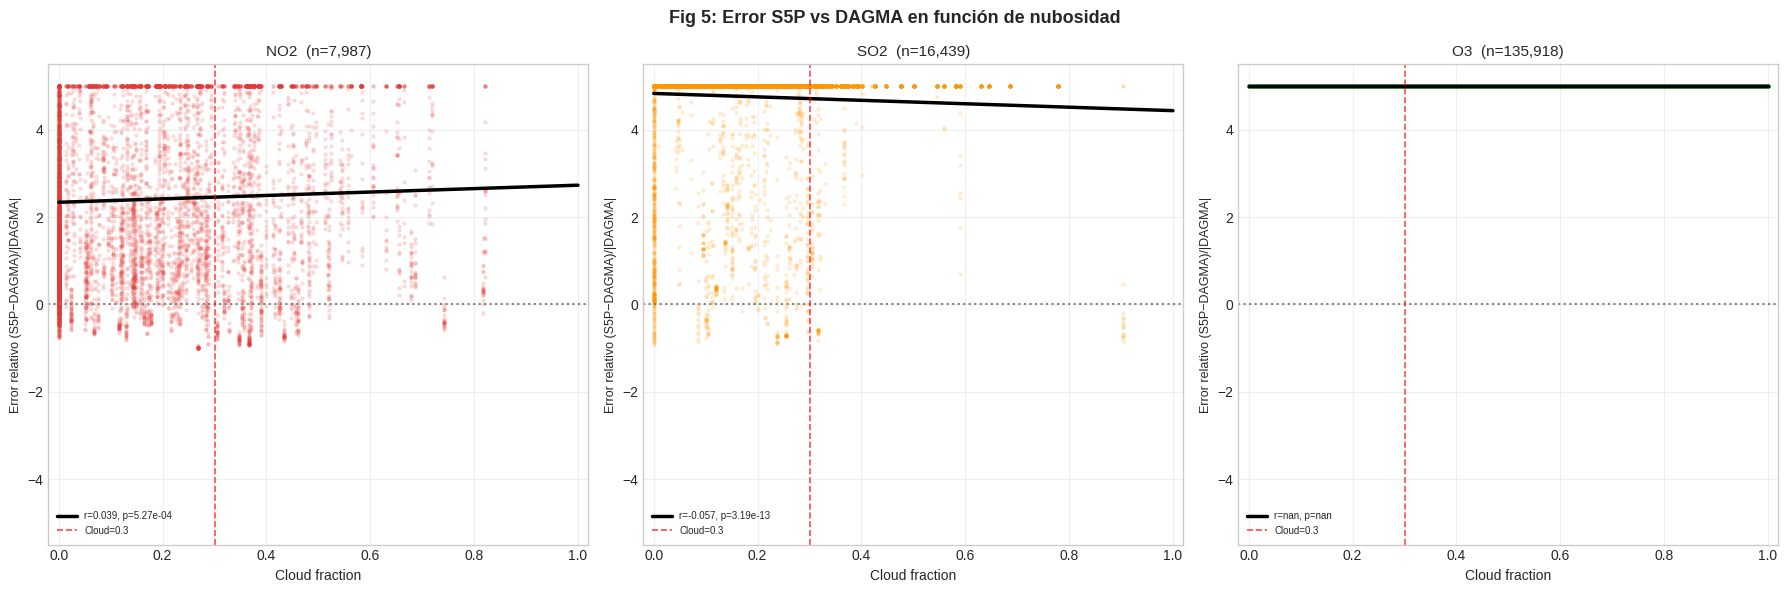

✓ 05_error_vs_nubes.png


PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion/05_error_vs_nubes.png')

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, TARGETS):
    dv = match_df[match_df["variable"] == var].copy()
    if len(dv) < 20:
        ax.text(0.5, 0.5, f"{var}: n={len(dv)}", ha="center", va="center",
                transform=ax.transAxes)
        continue

    dv["error"] = (dv["s5p_umol"] - dv["dagma"]) / (dv["dagma"].abs() + 1e-10)
    dv["error"] = dv["error"].clip(-5, 5)

    ax.scatter(dv["cloud_frac"], dv["error"],
               alpha=0.12, s=5, c=COLORS[var])

    # Tendencia lineal
    mask = dv[["cloud_frac","error"]].notna().all(axis=1)
    sl, ic, r, p, _ = stats.linregress(dv.loc[mask,"cloud_frac"], dv.loc[mask,"error"])
    ax.plot([0, 1], [ic, sl + ic], "k-", lw=2.5, label=f"r={r:.3f}, p={p:.2e}")

    # Línea de sesgo cero
    ax.axhline(0, color="gray", ls=":", lw=1.5)

    # Umbral de nube
    ax.axvline(0.3, color="red", ls="--", lw=1.2, alpha=0.7, label="Cloud=0.3")

    ax.set_xlabel("Cloud fraction", fontsize=10)
    ax.set_ylabel("Error relativo (S5P−DAGMA)/|DAGMA|", fontsize=9)
    ax.set_title(f"{var}  (n={len(dv):,})", fontsize=11)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-5.5, 5.5)

fig.suptitle("Fig 5: Error S5P vs DAGMA en función de nubosidad",
             fontweight="bold", fontsize=13)
fig.tight_layout()
savefig("05_error_vs_nubes")


### Fig 6 · RMSE móvil en el tiempo (ventana 30 días)

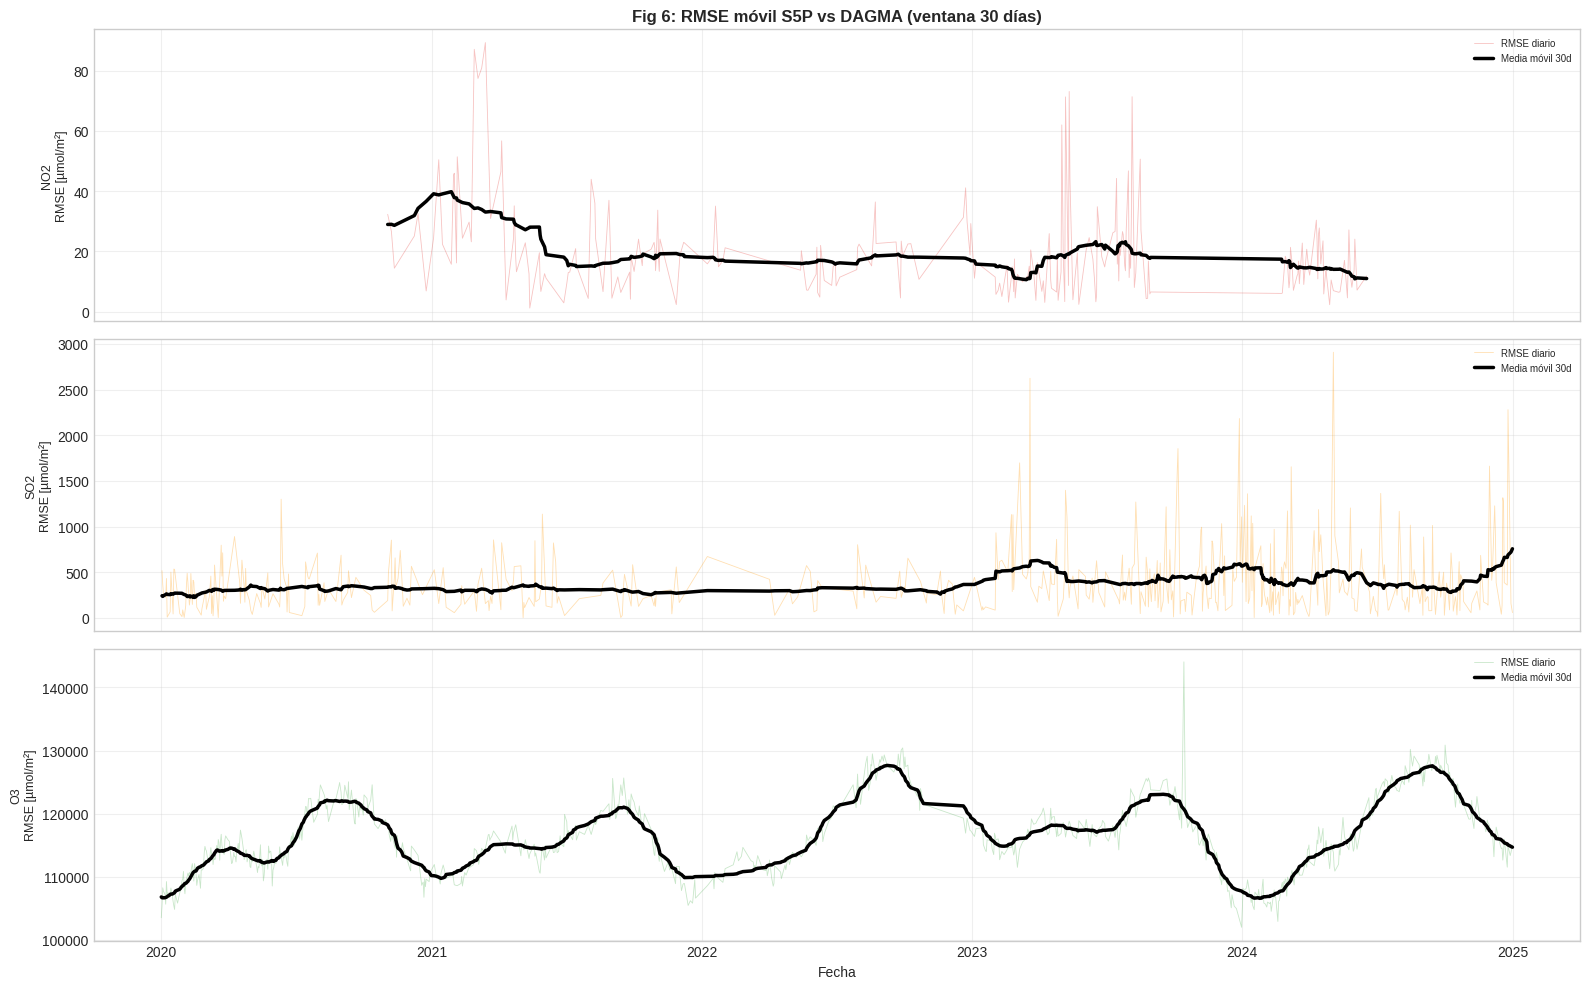

✓ 06_rmse_movil.png


PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion/06_rmse_movil.png')

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, var in zip(axes, TARGETS):
    dv = match_df[(match_df["variable"] == var) & match_df["is_clean"]]
    if len(dv) < 30:
        ax.text(0.5, 0.5, f"{var}: datos insuficientes", ha="center", va="center",
                transform=ax.transAxes)
        continue

    rmse_vals, rmse_dates = [], []
    for fecha in sorted(dv["fecha"].unique()):
        dfecha = dv[dv["fecha"] == fecha]
        if len(dfecha) < 2: continue
        rmse = np.sqrt(np.mean((dfecha["s5p_umol"] - dfecha["dagma"])**2))
        rmse_vals.append(rmse); rmse_dates.append(fecha)

    rolling = pd.Series(rmse_vals).rolling(30, min_periods=5, center=True).mean()

    ax.plot(rmse_dates, rmse_vals,
            alpha=0.3, lw=0.6, color=COLORS[var], label="RMSE diario")
    ax.plot(rmse_dates, rolling.values,
            lw=2.5, color="black", label="Media móvil 30d")

    ax.set_ylabel(f"{var}\nRMSE [µmol/m²]", fontsize=9)
    ax.legend(fontsize=7, loc="upper right"); ax.grid(alpha=0.3)

axes[0].set_title("Fig 6: RMSE móvil S5P vs DAGMA (ventana 30 días)",
                  fontweight="bold", fontsize=12)
axes[-1].set_xlabel("Fecha")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
savefig("06_rmse_movil")


---
## ✅ Resumen

In [10]:
figs = sorted(OUT_DIR.glob("*.png"))
print(f"Figuras guardadas en: {OUT_DIR}")
print(f"Total: {len(figs)} archivos\n")
for i, p in enumerate(figs, 1):
    print(f"  {i}. {p.name}")

# Estadísticas resumidas por variable
print("\n── Estadísticas del emparejamiento ──")
for var in TARGETS:
    dv = match_df[(match_df["variable"] == var) & match_df["is_clean"]]
    if len(dv) < 5: continue
    r, _ = stats.pearsonr(dv["dagma"], dv["s5p_umol"])
    rmse = np.sqrt(np.mean((dv["s5p_umol"] - dv["dagma"])**2))
    bias = (dv["s5p_umol"] - dv["dagma"]).mean()
    print(f"  {var:>3s}  n={len(dv):5,}  r={r:.3f}  RMSE={rmse:.4f}  Sesgo={bias:+.4f}")


Figuras guardadas en: /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/validacion
Total: 6 archivos

  1. 01_scatter_s5p_vs_dagma.png
  2. 02_serie_temporal_dual.png
  3. 03_mapa_sesgo.png
  4. 04_diagrama_taylor.png
  5. 05_error_vs_nubes.png
  6. 06_rmse_movil.png

── Estadísticas del emparejamiento ──
  NO2  n=6,058  r=0.200  RMSE=24.2910  Sesgo=+17.1850
  SO2  n=15,358  r=-0.070  RMSE=531.1945  Sesgo=+363.7199
   O3  n=42,618  r=0.026  RMSE=116460.9964  Sesgo=+116311.7202
